In [ ]:
# !pip install pyqubo
# Deprecated-1.3.1 dimod-0.12.21 dwave-neal-0.6.0 dwave-samplers-1.7.0 networkx-3.6.1 pyqubo-1.5.0 wrapt-2.1.1

In [30]:
import numpy as np
from pyqubo import Spin
from pyqubo import Array
import neal
import networkx as nx
import matplotlib.pyplot as plt
import math 
import random
from collections import Counter

1) Problem size and graph setup

In [31]:
N = 10  # number of spins (and graph nodes)

G = nx.Graph()                 # graph for visualization
h = np.zeros(N)                # Ising linear terms (local fields): sum_i h[i] s_i
B = np.zeros((N, N))           # symmetric matrix version of couplers (for printing)
J = {}                         # Ising couplers as a dict: sum_{i<j} J[(i,j)] s_i s_j

2) Randomly generate local fields h and add nodes

In [32]:
for i in range(N):
    h[i] = round(random.uniform(-1, 1), 1)   # random in [-1,1], rounded
    G.add_node(i, label=h[i])                # store the field as a node attribute

print("------------------------")
print("local fields h (switches)")
print("------------------------")
print(h)
print("------------------------")

# Random node positions for drawing
pos = nx.random_layout(G)

------------------------
local fields h (switches)
------------------------
[ 0.9 -0.4 -0.4 -0.8 -0.6  0.2  0.7 -0.5  0.2  0.4]
------------------------


3) Randomly add couplers between pairs (i,j)

In [33]:
edge_prob = 0.3

for i in range(N):
    for j in range(i + 1, N):
        if random.uniform(0, 1) < edge_prob:
            Jij = round(random.uniform(-1, 1), 1)  # random coupling in [-1,1]
            G.add_edge(i, j)

            # Store in dict form (standard Ising)
            J[(i, j)] = Jij

            # Store symmetrically in matrix form (for printing / inspection)
            B[i, j] = Jij
            B[j, i] = Jij


# FIX: ensure no isolated nodes

isolated = list(nx.isolates(G))  # nodes with degree 0

for u in isolated:
    # pick a random different node to connect to
    v = random.choice([x for x in range(N) if x != u])

    # avoid duplicates (rare here, but safe)
    if not G.has_edge(u, v):
        Jij = round(random.uniform(-1, 1), 1)

        G.add_edge(u, v)
        i, j = (u, v) if u < v else (v, u)

        J[(i, j)] = Jij
        B[i, j] = Jij
        B[j, i] = Jij

print("couplers matrix B (symmetric)")
print("------------------------")
print(B)

couplers matrix B (symmetric)
------------------------
[[ 0.  -0.5  0.   0.   0.   0.   0.   0.  -0.4 -0.6]
 [-0.5  0.   0.   0.1  0.   0.   0.8  0.6  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.9  0.   0.   0.   0. ]
 [ 0.   0.1  0.   0.   0.   0.  -0.6  0.   0.   1. ]
 [ 0.   0.   0.   0.   0.  -0.1  0.   0.4  0.   0.5]
 [ 0.   0.   0.9  0.  -0.1  0.   0.9  0.   0.6  0. ]
 [ 0.   0.8  0.  -0.6  0.   0.9  0.   0.  -0.9  0. ]
 [ 0.   0.6  0.   0.   0.4  0.   0.   0.   0.  -0.2]
 [-0.4  0.   0.   0.   0.   0.6 -0.9  0.   0.  -0.5]
 [-0.6  0.   0.   1.   0.5  0.   0.  -0.2 -0.5  0. ]]


Plot the graph, with weights and labels:

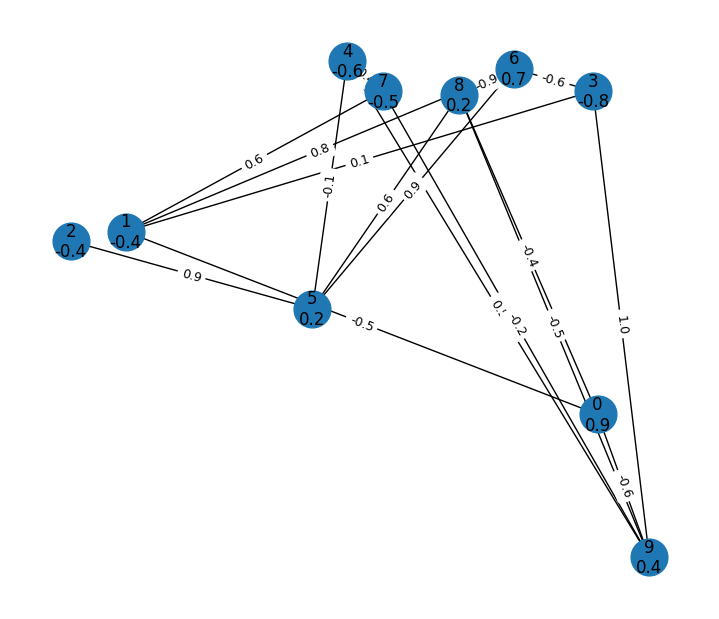

In [34]:
plt.figure(figsize=(7, 6))
node_labels = {i: f"{i}\n{h[i]:.1f}" for i in range(N)}  # index + local field
nx.draw(
    G,
    pos=pos,
    labels=node_labels,
    node_size=700
)

# Build edge-label dict in the format {(i,j): value}
edge_labels = {(i, j): Jij for (i, j), Jij in J.items()}

# Draw the coupling values on the edges
nx.draw_networkx_edge_labels(
    G,
    pos=pos,
    edge_labels=edge_labels,
    font_size=9
)

plt.axis("off")
plt.show()

4) Build the Hamiltonian in PyQUBO using SPIN variables s[i] in {-1,+1}       

    $ H = \sum_i h[i] s[i] + \sum_{i<j} J[(i,j)] s[i] s[j]$

In [35]:
s = Array.create('s', shape=N, vartype='SPIN')

H = 0
# linear terms
for i in range(N):
    H += h[i] * s[i]

# quadratic terms (iterate only over existing couplers)
for (i, j), Jij in J.items():
    H += Jij * s[i] * s[j]

# Compile and convert to Ising form (h_dict, J_dict, offset)
model = H.compile()
ising = model.to_ising()

# NOTE:
# Many PyQUBO versions return (h_dict, J_dict, offset).
# We’ll handle either case safely.
if len(ising) == 3:
    h_dict, J_dict, offset = ising
else:
    h_dict, J_dict = ising
    offset = 0.0

5) Solve with simulated annealing (neal)

In [36]:
sa = neal.SimulatedAnnealingSampler()
sampleset = sa.sample_ising(h_dict, J_dict, num_reads=1000)

# Decode samples back into variable names like "s[0]" and energies
decoded_samples = model.decode_sampleset(sampleset)

6) Histogram of all sampled solutions 

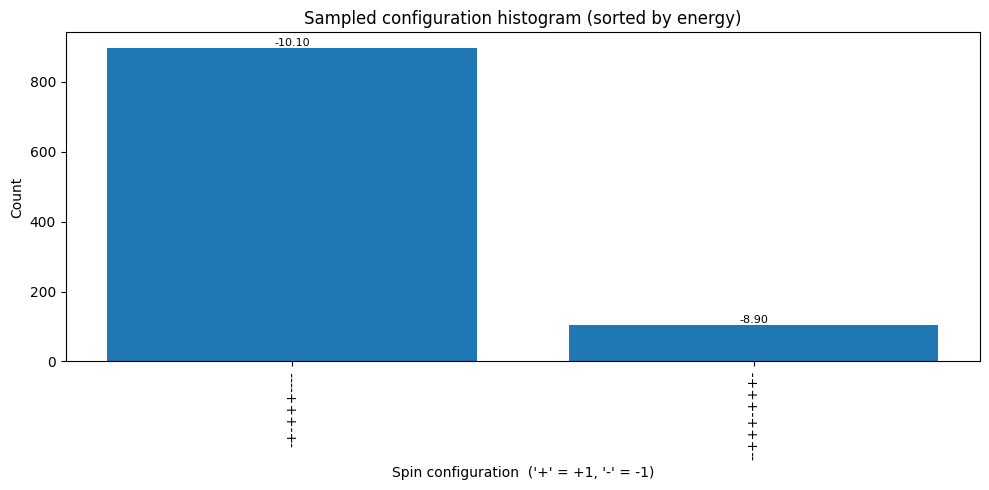

In [45]:
def spins_to_str_from_sample(sample_dict, N):
    return ''.join('+' if sample_dict[f"s[{i}]"] == 1 else '-' for i in range(N))

# Build config strings + energies directly from decoded_samples
configs = [spins_to_str_from_sample(samp.sample, N) for samp in decoded_samples]
energies = [samp.energy for samp in decoded_samples]

# Count how many times each configuration appears
config_counts = Counter(configs)

# Store ONE energy per configuration (use the minimum observed energy for that config)
config_energy = {}
for cfg, E in zip(configs, energies):
    config_energy[cfg] = min(E, config_energy.get(cfg, E))

# Sort by energy then by frequency
configs_sorted = sorted(config_counts.keys(), key=lambda c: (config_energy[c], -config_counts[c]))
counts_sorted = [config_counts[c] for c in configs_sorted]

# Plot
fig_w = max(10, 0.55 * len(configs_sorted))
plt.figure(figsize=(fig_w, 5))
bars = plt.bar(range(len(configs_sorted)), counts_sorted)

plt.xticks(range(len(configs_sorted)), configs_sorted, rotation=90)
plt.ylabel("Count")
plt.xlabel("Spin configuration  ('+' = +1, '-' = -1)")
plt.title("Sampled configuration histogram (sorted by energy)")

# Annotate each bar with its energy
for i, cfg in enumerate(configs_sorted):
    E = config_energy[cfg]
    y = counts_sorted[i]
    plt.text(i, y + 0.05, f"{E:.2f}", ha="center", va="bottom", fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

7) Print the solution

In [46]:
# Best (minimum energy) decoded sample
best_sample = min(decoded_samples, key=lambda x: x.energy)
print("Best decoded sample dict:")
print(best_sample.sample)

print("------------------------")

# Extract spin configurations into plain lists, without the keys

sols = []
for samp in decoded_samples:
    sols.append([samp.sample[f"s[{i}]"] for i in range(N)])

# Best configuration as a plain list of spins
best_sol = [best_sample.sample[f"s[{i}]"] for i in range(N)]
print("Best spin configuration:")
print(best_sol)

print("------------------------")

# Best energy: you can just use best_sample.energy
print("Best energy (from decoded_samples):")
print(best_sample.energy)

Best decoded sample dict:
{'s[0]': -1, 's[1]': 1, 's[2]': -1, 's[3]': 1, 's[4]': 1, 's[5]': 1, 's[6]': -1, 's[7]': -1, 's[8]': -1, 's[9]': -1}
------------------------
Best spin configuration:
[-1, 1, -1, 1, 1, 1, -1, -1, -1, -1]
------------------------
Best energy (from decoded_samples):
-10.099999999999998
